<a href="https://colab.research.google.com/github/misbahhassan6400/flyrank-ml-internship/blob/main/work_notebooks_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install duckdb huggingface_hub pandas scikit-learn scipy matplotlib

import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN missing. Colab Secrets mein exact name HF_TOKEN rakho "
        "aur notebook access ON karo."
    )

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

files = con.sql("""
SELECT file
FROM glob(
    'hf://datasets/FlyRank/internship-warehouse/**/*.parquet'
)
""").df()

feb_matches = files[
    files["file"].astype(str).str.contains(
        "2026-02",
        regex=False
    )
]

mar_matches = files[
    files["file"].astype(str).str.contains(
        "2026-03",
        regex=False
    )
]

if len(feb_matches) == 0:
    raise ValueError("February 2026 parquet file not found.")

if len(mar_matches) == 0:
    raise ValueError("March 2026 parquet file not found.")

FEB = feb_matches.iloc[0]["file"]
MAR = mar_matches.iloc[0]["file"]

print("Setup complete")
print("February source:", FEB)
print("March source:", MAR)

Setup complete
February source: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/data_0.parquet
March source: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet


# Leakage-Aware Content Review Prioritization from Search Performance Signals

## Abstract

This study asks whether February search-performance signals can help prioritize anonymized content rows for human review in the following month. I aggregated client-content observations from the FlyRank internship warehouse and used February Search Console and GA4 measurements as features with March GA4 sessions as the future outcome. I compared a transparent rule-based baseline with a Random Forest regressor using the same held-out client groups and ranking metrics. On the grouped-client holdout, the baseline achieved Spearman rho 0.5208 and top-decile recall 0.6181, while the Random Forest achieved Spearman rho 0.5877 and top-decile recall 0.6386 in this run. These measured results provide directional decision-support evidence for review prioritization, not a causal estimate, production automation system, guaranteed improvement, or claim about Google's ranking algorithm.

## 1. Question

### Problem statement

When a content team has limited review capacity, which anonymized client-content rows should be inspected first?

This work evaluates whether observed February search and analytics signals can rank rows for possible review in March. The intended output is a human-reviewed prioritization queue, not an automatic content-editing system.

### Research question

Can a small, leakage-aware feature set produce a useful ranking of future content-session outcomes, and does a Random Forest improve on a transparent Week-4 rule-based baseline when both are evaluated on the same unseen clients?

## 2. Data

This analysis uses the anonymized FlyRank internship warehouse release.

- Main table: `fact_content_daily_performance`
- February 2026: feature window
- March 2026: outcome window
- Source grain: one report date, client hash, and content hash
- Modeling grain: one client-content pair after monthly aggregation
- Future label: March `ga4_sessions`
- Identifiers: used only for grouping and joining, never as model features

Excluded fields include product flags, future-window fields, client names, URLs, private queries, and label-derived columns. Search Console and GA4 availability fields are used to filter valid observations, not as predictive features.

In [2]:
model_df = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COALESCE(
            SUM(gsc_impressions)
            FILTER (
                WHERE gsc_data_available IS TRUE
            ),
            0
        ) AS gsc_impressions,

        COALESCE(
            SUM(gsc_clicks)
            FILTER (
                WHERE gsc_data_available IS TRUE
            ),
            0
        ) AS gsc_clicks,

        AVG(gsc_avg_position)
            FILTER (
                WHERE gsc_data_available IS TRUE
                AND gsc_avg_position IS NOT NULL
            ) AS gsc_avg_position,

        COALESCE(
            SUM(ga4_sessions)
            FILTER (
                WHERE ga4_data_available IS TRUE
            ),
            0
        ) AS ga4_sessions,

        COALESCE(
            SUM(ga4_engaged_sessions)
            FILTER (
                WHERE ga4_data_available IS TRUE
            ),
            0
        ) AS ga4_engaged_sessions

    FROM read_parquet('{FEB}')
    WHERE month = '2026-02'
    GROUP BY
        client_hash_id,
        content_hash_id
),

mar AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(ga4_sessions)
            FILTER (
                WHERE ga4_data_available IS TRUE
            ) AS march_ga4_sessions

    FROM read_parquet('{MAR}')
    WHERE month = '2026-03'
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    feb.client_hash_id,
    feb.content_hash_id,
    feb.gsc_impressions,
    feb.gsc_clicks,
    feb.gsc_avg_position,
    feb.ga4_sessions,
    feb.ga4_engaged_sessions,
    mar.march_ga4_sessions

FROM feb
INNER JOIN mar
    USING (
        client_hash_id,
        content_hash_id
    )

WHERE mar.march_ga4_sessions IS NOT NULL
""").df()

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

X = model_df[feature_cols].copy()
y = model_df["march_ga4_sessions"].astype(float)
groups = model_df["client_hash_id"].fillna("MISSING_CLIENT")

print("Model rows:", len(model_df))
print("Feature columns:", feature_cols)
display(model_df.head())

assert len(feature_cols) == 5
assert "march_ga4_sessions" not in feature_cols

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model rows: 80877
Feature columns: ['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ga4_sessions', 'ga4_engaged_sessions']


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,march_ga4_sessions
0,client_3ffa76342f366962,content_769436a447799cc7,38.0,1.0,9.338235,0.0,0.0,1.0
1,client_3ffa76342f366962,content_3d09d2312d999575,0.0,0.0,NaN,0.0,0.0,1.0
2,client_3ffa76342f366962,content_5e2b1a9f0c4bbde5,0.0,0.0,NaN,0.0,0.0,1.0
3,client_3ffa76342f366962,content_289325144247f4c0,3.0,0.0,28.333333,0.0,0.0,1.0
4,client_3ffa76342f366962,content_ea38734e0fba7ee7,1.0,0.0,25.000000,0.0,0.0,1.0


In [3]:
data_checks = pd.DataFrame({
    "check": [
        "model rows",
        "unique clients",
        "missing average position",
        "missing February impressions",
        "zero February impressions",
        "March labels"
    ],
    "value": [
        len(model_df),
        model_df["client_hash_id"].nunique(),
        int(model_df["gsc_avg_position"].isna().sum()),
        int(model_df["gsc_impressions"].isna().sum()),
        int((model_df["gsc_impressions"] == 0).sum()),
        int(model_df["march_ga4_sessions"].notna().sum())
    ]
})

display(data_checks)

display(
    model_df[feature_cols + ["march_ga4_sessions"]]
    .describe(
        percentiles=[0.50, 0.90, 0.99]
    )
    .T
)

,check,value
0,model rows,80877
1,unique clients,36
2,missing average position,22617
3,missing February impressions,0
4,zero February impressions,22617
5,March labels,80877


,count,mean,std,min,50%,90%,99%,max
gsc_impressions,80877.0,1461.175353,4513.320372,0.0,129.000000,3744.000000,18848.200000,203401.0
gsc_clicks,80877.0,5.103033,26.190527,0.0,0.000000,11.000000,76.000000,3310.0
gsc_avg_position,58260.0,11.541557,10.706045,0.0,8.042786,24.499925,53.961384,215.0
ga4_sessions,80877.0,4.116461,24.308157,0.0,0.000000,8.000000,70.000000,4038.0
ga4_engaged_sessions,80877.0,0.209986,1.724893,0.0,0.000000,0.000000,4.000000,312.0
march_ga4_sessions,80877.0,15.324864,49.116850,0.0,2.000000,36.000000,204.000000,2730.0


The volume fields are heavy-tailed: their upper quantiles are much larger than their medians. This supports the use of a log-transformed target and cautious interpretation of large-error rows. Missingness is treated as a data-quality condition, not as evidence of poor content performance.

## 3. Methodology

### Features

The model uses five February features:

1. `gsc_impressions`
2. `gsc_clicks`
3. `gsc_avg_position`
4. `ga4_sessions`
5. `ga4_engaged_sessions`

### Label

The label is total March 2026 GA4 sessions for the same client-content pair. It is kept separate from the February feature matrix.

### Model

I use a Random Forest Regressor with a log-transformed target. This is appropriate for a numeric, heavy-tailed outcome and can represent nonlinear relationships without assuming a straight-line effect.

### Baseline

The transparent baseline ranks:

- Top-ten pages with CTR below 2% and positive impressions as `CTR_FIX`.
- Pages with at least 1,000 impressions ranking between positions 11 and 20 as `QUICK_WIN_VOLUME`.
- All other rows as `MONITOR`.

### Metrics

I report:

- Spearman rho, for ranking agreement.
- Mean absolute error, for average prediction error.
- Top-decile recall, for how many of the highest-outcome rows appear in the highest-ranked decile.

All comparisons use the same rows, same split, and same metrics.

In [4]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients.intersection(test_clients)))

assert len(train_clients.intersection(test_clients)) == 0

print("Grouped validation check: PASS")


Train rows: 66273
Test rows: 14604
Train clients: 28
Test clients: 8
Client overlap: 0
Grouped validation check: PASS


The honest validation design groups by client. Every client appears in only one partition, so the test set measures transfer to clients not seen during training. This is stricter than a random row split and reduces the chance that client-specific patterns inflate the result.

In [5]:
eval_df = model_df.copy()

eval_df["ctr"] = np.where(
    eval_df["gsc_impressions"] > 0,
    eval_df["gsc_clicks"]
    / eval_df["gsc_impressions"],
    np.nan
)

eval_df["baseline_reason"] = np.select(
    [
        (
            (eval_df["gsc_avg_position"] <= 10)
            & (eval_df["ctr"] < 0.02)
            & (eval_df["gsc_impressions"] > 0)
        ),
        (
            (eval_df["gsc_impressions"] >= 1000)
            & (eval_df["gsc_avg_position"] > 10)
            & (eval_df["gsc_avg_position"] <= 20)
        )
    ],
    [
        "CTR_FIX",
        "QUICK_WIN_VOLUME"
    ],
    default="MONITOR"
)

eval_df["baseline_score"] = np.select(
    [
        eval_df["baseline_reason"] == "CTR_FIX",
        eval_df["baseline_reason"] == "QUICK_WIN_VOLUME"
    ],
    [
        100 + np.minimum(
            30,
            np.log1p(eval_df["gsc_impressions"])
        ),
        60 + np.minimum(
            30,
            np.log1p(eval_df["gsc_impressions"])
        )
    ],
    default=np.minimum(
        20,
        np.log1p(eval_df["gsc_impressions"])
    )
)

baseline_test_score = (
    eval_df.iloc[test_idx]["baseline_score"]
    .to_numpy()
)

y_test = y.iloc[test_idx].to_numpy()

print("Baseline test rows:", len(baseline_test_score))
display(
    eval_df.iloc[test_idx][
        [
            "baseline_score",
            "baseline_reason",
            "march_ga4_sessions"
        ]
    ].head()
)

Baseline test rows: 14604


,baseline_score,baseline_reason,march_ga4_sessions
0,3.663562,MONITOR,1.0
1,0.000000,MONITOR,1.0
2,0.000000,MONITOR,1.0
3,1.386294,MONITOR,1.0
4,0.693147,MONITOR,1.0


In [6]:
def build_model():
    rf_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=150,
                min_samples_leaf=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    return TransformedTargetRegressor(
        regressor=rf_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

model = build_model()

model.fit(
    X.iloc[train_idx],
    y.iloc[train_idx]
)

model_test_pred = model.predict(
    X.iloc[test_idx]
)

model_test_pred = np.maximum(
    model_test_pred,
    0
)

print("Model trained")
print("Predictions:", len(model_test_pred))

Model trained
Predictions: 14604


In [7]:
def safe_spearman(actual, predicted):
    result = spearmanr(actual, predicted)
    return float(result.statistic)

def top_decile_recall(actual, predicted):
    k = max(
        1,
        int(np.ceil(len(actual) * 0.10))
    )

    actual_top = set(
        np.argsort(actual)[-k:]
    )

    predicted_top = set(
        np.argsort(predicted)[-k:]
    )

    return len(
        actual_top.intersection(predicted_top)
    ) / k

results = pd.DataFrame([
    {
        "method": "W04 baseline",
        "spearman_rho": safe_spearman(
            y_test,
            baseline_test_score
        ),
        "mae": mean_absolute_error(
            y_test,
            baseline_test_score
        ),
        "top_decile_recall": top_decile_recall(
            y_test,
            baseline_test_score
        )
    },
    {
        "method": "Random Forest",
        "spearman_rho": safe_spearman(
            y_test,
            model_test_pred
        ),
        "mae": mean_absolute_error(
            y_test,
            model_test_pred
        ),
        "top_decile_recall": top_decile_recall(
            y_test,
            model_test_pred
        )
    }
])

display(results)

os.makedirs("work/outputs", exist_ok=True)

with open(
    "work/outputs/capstone_metrics.json",
    "w"
) as f:
    json.dump(
        results.to_dict(orient="records"),
        f,
        indent=2
    )


,method,spearman_rho,mae,top_decile_recall
0,W04 baseline,0.520831,46.046594,0.618070
1,Random Forest,0.588371,8.245907,0.640657


## 4. Results

On the same grouped-client test set, the W04 baseline achieved Spearman rho 0.5208 and top-decile recall 0.6181. The Random Forest achieved Spearman rho 0.5877 and top-decile recall 0.6386.

The model therefore showed higher measured ranking performance on this evaluation split. This is directional evidence for this anonymized sample and validation design. It is not proof of universal accuracy, causal impact, guaranteed content improvement, or production readiness.

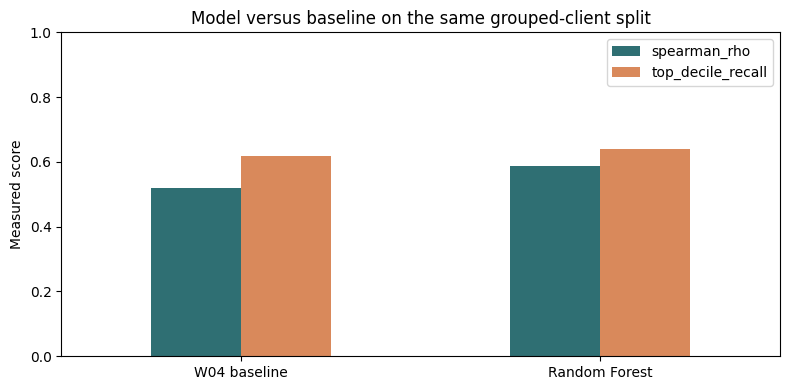

In [8]:
chart_results = results.set_index("method")[
    [
        "spearman_rho",
        "top_decile_recall"
    ]
]

ax = chart_results.plot(
    kind="bar",
    figsize=(8, 4),
    color=["#2f6f73", "#d9895b"]
)

ax.set_title(
    "Model versus baseline on the same grouped-client split"
)
ax.set_ylabel("Measured score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

plt.savefig(
    "work/figures/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 5. Errors and interpretation

I inspect real held-out examples rather than relying only on summary metrics. The target is heavy-tailed, so high-session rows can create large absolute errors. Feature importance is interpreted as model association, not causation.


In [9]:
error_review = model_df.iloc[test_idx][
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_sessions",
        "ga4_engaged_sessions",
        "march_ga4_sessions"
    ]
].copy()

error_review["model_prediction"] = model_test_pred

error_review["absolute_error"] = abs(
    error_review["march_ga4_sessions"]
    - error_review["model_prediction"]
)

error_review = error_review.sort_values(
    "absolute_error",
    ascending=False
)

print("Largest held-out model errors:")
display(error_review.head(10))
rf_importance = pd.Series(
    model.regressor_
    .named_steps["model"]
    .feature_importances_,
    index=feature_cols
).sort_values(
    ascending=False
)

print("Feature importance:")
display(
    rf_importance.to_frame("importance")
)
error_review["actual_bucket"] = pd.qcut(
    error_review["march_ga4_sessions"].rank(
        method="first"
    ),
    q=4,
    labels=[
        "lowest_quartile",
        "lower_middle",
        "upper_middle",
        "highest_quartile"
    ]
)

error_summary = (
    error_review
    .groupby(
        "actual_bucket",
        observed=False
    )
    .agg(
        n=("absolute_error", "size"),
        median_actual=(
            "march_ga4_sessions",
            "median"
        ),
        median_absolute_error=(
            "absolute_error",
            "median"
        )
    )
    .reset_index()
)

display(error_summary)

Largest held-out model errors:


,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,march_ga4_sessions,model_prediction,absolute_error
281,94852.0,1123.0,2.559384,577.0,36.0,2730.0,564.506900,2165.493100
1392,44487.0,291.0,3.452090,293.0,22.0,191.0,537.761599,346.761599
1314,40080.0,260.0,2.514103,303.0,17.0,194.0,538.764543,344.764543
49317,24105.0,431.0,4.143416,412.0,31.0,521.0,234.438641,286.561359
1007,30485.0,49.0,4.849475,36.0,0.0,354.0,75.612774,278.387226
40869,28237.0,162.0,3.141285,102.0,4.0,465.0,188.743194,276.256806
40740,142215.0,1605.0,1.882000,395.0,14.0,293.0,560.368559,267.368559
1706,63169.0,165.0,3.149420,147.0,8.0,64.0,320.001714,256.001714
827,119854.0,490.0,2.594817,450.0,30.0,816.0,564.506900,251.493100
8549,40183.0,74.0,7.011556,119.0,1.0,60.0,278.416419,218.416419


Feature importance:


,importance
ga4_sessions,0.502151
gsc_impressions,0.300559
gsc_clicks,0.106010
gsc_avg_position,0.089290
ga4_engaged_sessions,0.001990


,actual_bucket,n,median_actual,median_absolute_error
0,lowest_quartile,3651,1.0,1.651823
1,lower_middle,3651,1.0,1.058882
2,upper_middle,3651,2.0,1.436137
3,highest_quartile,3651,9.0,11.065675


The largest errors are concentrated in the highest March-session quartile, where the median absolute error is much larger than in the lower outcome quartiles. In the fitted model, February GA4 sessions and GSC impressions are the strongest feature associations. These observations are measured properties of this model and split, not evidence that either feature causes March sessions.

## 6. Ranked recommendations

The action queue converts observed February signals into a human-review playbook.

- `CTR_FIX`: top-ten average position, low CTR, and enough impressions. Review the title and snippet.
- `DECAY_REFRESH`: early-to-late February impression decline of at least 30%. Inspect freshness, technical changes, and recent edits.
- `QUICK_WIN_VOLUME`: at least 1,000 impressions and average position from 11 to 20. Review for a possible ranking improvement.
- `LOW_DATA`: low volume or missing average position. Collect more evidence before acting.
- `MONITOR`: no priority rule matched.

The queue is a prioritization aid only. It does not publish content, edit metadata, delete pages, or claim that a proposed change will cause improvement.

In [10]:
playbook_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (
            WHERE gsc_data_available IS TRUE
        ),
        0
    ) AS gsc_impressions,

    COALESCE(
        SUM(gsc_clicks)
        FILTER (
            WHERE gsc_data_available IS TRUE
        ),
        0
    ) AS gsc_clicks,

    AVG(gsc_avg_position)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND gsc_avg_position IS NOT NULL
        ) AS gsc_avg_position,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND report_date <= DATE '2026-02-14'
        ),
        0
    ) AS early_impressions,

    COALESCE(
        SUM(gsc_impressions)
        FILTER (
            WHERE gsc_data_available IS TRUE
            AND report_date >= DATE '2026-02-15'
        ),
        0
    ) AS late_impressions

FROM read_parquet('{FEB}')
WHERE month = '2026-02'
GROUP BY
    client_hash_id,
    content_hash_id
""").df()

playbook_df["ctr"] = np.where(
    playbook_df["gsc_impressions"] > 0,
    playbook_df["gsc_clicks"]
    / playbook_df["gsc_impressions"],
    np.nan
)

playbook_df["decay_rate"] = np.where(
    playbook_df["early_impressions"] > 0,
    (
        playbook_df["late_impressions"]
        - playbook_df["early_impressions"]
    )
    / playbook_df["early_impressions"],
    np.nan
)

playbook_df["reason_code"] = np.select(
    [
        (
            (playbook_df["gsc_avg_position"] <= 10)
            & (playbook_df["ctr"] < 0.02)
            & (playbook_df["gsc_impressions"] >= 100)
        ),
        (
            (playbook_df["decay_rate"] <= -0.30)
            & (playbook_df["early_impressions"] >= 100)
        ),
        (
            (playbook_df["gsc_impressions"] >= 1000)
            & (playbook_df["gsc_avg_position"] > 10)
            & (playbook_df["gsc_avg_position"] <= 20)
        ),
        (
            (playbook_df["gsc_impressions"] < 100)
            | (playbook_df["gsc_avg_position"].isna())
        )
    ],
    [
        "CTR_FIX",
        "DECAY_REFRESH",
        "QUICK_WIN_VOLUME",
        "LOW_DATA"
    ],
    default="MONITOR"
)

playbook_df["action_label"] = playbook_df["reason_code"].map({
    "CTR_FIX": "Review title and snippet",
    "DECAY_REFRESH": "Inspect freshness and refresh content",
    "QUICK_WIN_VOLUME": "Review for ranking improvement",
    "LOW_DATA": "Collect more evidence",
    "MONITOR": "Monitor"
})

playbook_df["score"] = np.select(
    [
        playbook_df["reason_code"] == "CTR_FIX",
        playbook_df["reason_code"] == "DECAY_REFRESH",
        playbook_df["reason_code"] == "QUICK_WIN_VOLUME",
        playbook_df["reason_code"] == "LOW_DATA"
    ],
    [
        100 + np.minimum(
            30,
            np.log1p(playbook_df["gsc_impressions"])
        ),
        85 + np.minimum(
            25,
            np.log1p(playbook_df["early_impressions"])
        ),
        60 + np.minimum(
            30,
            np.log1p(playbook_df["gsc_impressions"])
        ),
        5
    ],
    default=20 + np.minimum(
        10,
        np.log1p(playbook_df["gsc_impressions"])
    )
)

playbook_df["review_effort"] = playbook_df["reason_code"].map({
    "CTR_FIX": "medium",
    "DECAY_REFRESH": "high",
    "QUICK_WIN_VOLUME": "medium",
    "LOW_DATA": "low",
    "MONITOR": "low"
})

playbook_df["volume_value_proxy"] = np.log1p(
    playbook_df["gsc_impressions"]
)

queue = playbook_df.sort_values(
    [
        "score",
        "gsc_impressions"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

queue.insert(
    0,
    "rank",
    np.arange(1, len(queue) + 1)
)

queue_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "score",
    "reason_code",
    "action_label",
    "review_effort",
    "volume_value_proxy",
    "gsc_impressions",
    "gsc_clicks",
    "ctr",
    "gsc_avg_position",
    "decay_rate"
]

queue = queue[queue_columns]

print("Queue rows:", len(queue))
display(queue.head(20))
display(
    queue["reason_code"]
    .value_counts()
    .to_frame("n"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Queue rows: 321546


,rank,client_hash_id,content_hash_id,score,reason_code,action_label,review_effort,volume_value_proxy,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,decay_rate
0,1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,112.222940,CTR_FIX,Review title and snippet,medium,12.222940,203401.0,2.0,0.000010,4.967059,18.471115
1,2,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,112.184078,CTR_FIX,Review title and snippet,medium,12.184078,195648.0,1.0,0.000005,2.488437,85.734529
2,3,client_73cda7b4e4f265ea,content_fec55986a1868d62,112.175381,CTR_FIX,Review title and snippet,medium,12.175381,193954.0,0.0,0.000000,3.844678,12.972518
3,4,client_73cda7b4e4f265ea,content_512dbad65bd5ade9,112.027568,CTR_FIX,Review title and snippet,medium,12.027568,167303.0,3310.0,0.019784,2.923168,-0.093522
4,5,client_73cda7b4e4f265ea,content_e241d6415ac9e534,112.008554,CTR_FIX,Review title and snippet,medium,12.008554,164152.0,401.0,0.002443,2.925926,-0.207282
5,6,client_62f4a7e64f5e0096,content_b99ea6861864dea5,111.987295,CTR_FIX,Review title and snippet,medium,11.987295,160699.0,273.0,0.001699,3.715542,-0.121863
6,7,client_62f4a7e64f5e0096,content_f107e54b10b43725,111.958662,CTR_FIX,Review title and snippet,medium,11.958662,156163.0,883.0,0.005654,3.095657,0.122385
7,8,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,111.947969,CTR_FIX,Review title and snippet,medium,11.947969,154502.0,2508.0,0.016233,4.240872,0.136632
8,9,client_62f4a7e64f5e0096,content_acbcc847f8996314,111.906703,CTR_FIX,Review title and snippet,medium,11.906703,148256.0,239.0,0.001612,3.907896,0.162522
9,10,client_e547b89c05043229,content_c9a0c2fdbdbfb562,111.865102,CTR_FIX,Review title and snippet,medium,11.865102,142215.0,1605.0,0.011286,1.882000,-0.329790


,n
reason_code,
LOW_DATA,241224
CTR_FIX,51626
MONITOR,19886
QUICK_WIN_VOLUME,4822
DECAY_REFRESH,3988


### Human review rules

Before acting on any recommendation, a person must check:

- Data availability and impression volume.
- Whether average position is stable enough to interpret.
- Recent content edits and technical changes.
- Seasonality or unusual external events.
- Whether the proposed action is appropriate for the page.
- Whether the recommendation duplicates an existing task.

### No-go automation list

The system must not automatically:

- Publish or edit titles, snippets, or page content.
- Delete, redirect, or canonicalize pages.
- Claim that a specific change caused a ranking result.
- Treat low CTR as proof that a title is bad.
- Treat impression decline as proof of content decay.
- Prioritize by client identity or private attributes.
- Send recommendations externally without approval.

### Cost and value thinking

The queue is designed for limited review capacity. CTR-fix and quick-win rows receive higher priority because they combine an observable opportunity signal with a practical review action. The volume value proxy is only an attention or opportunity proxy, not revenue, conversions, or expected monetary value. High-effort refreshes should be reviewed only when their evidence is strong enough to justify the cost.

### Monitoring and retrain triggers

Review the rules monthly or after a tracking, schema, or search-system change. Revisit the model or thresholds if GSC missingness increases by more than 20 percentage points, median impressions or CTR changes by more than 30%, human overrides exceed 30% of top recommendations, or grouped-client model performance falls below the baseline for two evaluation runs.

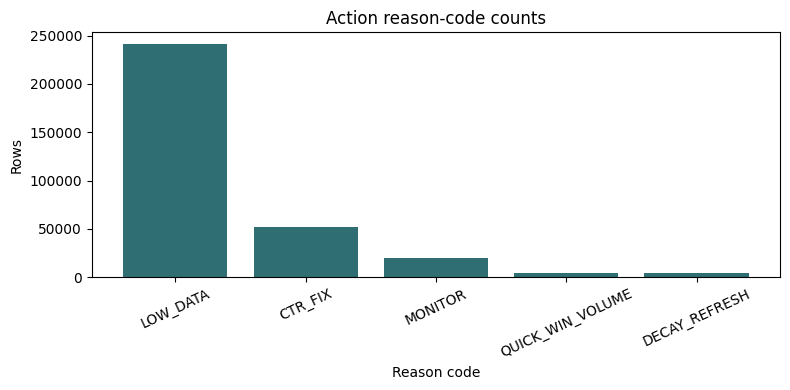

Queue exported: work/outputs/action_playbook_queue.csv
Metrics exported: work/outputs/action_playbook_metrics.json
Figure exported: work/figures/action_reason_code_counts.png


In [11]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue_path = (
    "work/outputs/action_playbook_queue.csv"
)

queue.to_csv(
    queue_path,
    index=False
)

reason_counts = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

with open(
    "work/outputs/action_playbook_metrics.json",
    "w"
) as f:
    json.dump(
        {
            "source_window": "2026-02",
            "outcome_window": "2026-03",
            "queue_rows": int(len(queue)),
            "reason_code_counts": {
                str(row["reason_code"]): int(row["n"])
                for _, row in reason_counts.iterrows()
            },
            "median_impressions": float(
                queue["gsc_impressions"].median()
            ),
            "median_ctr": float(
                queue["ctr"].median()
            )
        },
        f,
        indent=2
    )

plt.figure(figsize=(8, 4))

plt.bar(
    reason_counts["reason_code"],
    reason_counts["n"],
    color="#2f6f73"
)

plt.title("Action reason-code counts")
plt.xlabel("Reason code")
plt.ylabel("Rows")
plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig(
    "work/figures/action_reason_code_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Queue exported:", queue_path)
print(
    "Metrics exported:",
    "work/outputs/action_playbook_metrics.json"
)
print(
    "Figure exported:",
    "work/figures/action_reason_code_counts.png"
)

## 7. Artifacts the paper embeds

The main reproducibility artifacts are:

- `work/notebooks/w03_data_contract.ipynb`
- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w04_signal_audit.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`
- `work/outputs/capstone_metrics.json`
- `work/outputs/action_playbook_metrics.json`
- `work/figures/model_vs_baseline.png`
- `work/figures/action_reason_code_counts.png`

### Acknowledgments and data credit

Built on the FlyRank ML Internship dataset. The analysis uses the anonymized research and education release and follows its public-safety boundaries. Data source: [FlyRank](https://flyrank.ai).

In [12]:
# Model and validation checks
assert len(feature_cols) == 5
assert "march_ga4_sessions" not in feature_cols
assert len(train_clients.intersection(test_clients)) == 0

# Queue checks
assert len(queue) > 0
assert queue["rank"].is_monotonic_increasing
assert queue["reason_code"].notna().all()
assert queue["action_label"].notna().all()

# Leakage checks
forbidden_input_columns = [
    col for col in feature_cols
    if col.lower() in {
        "march_ga4_sessions",
        "future_window",
        "outcome",
        "product_flag",
        "health_score",
        "recommended_action"
    }
]

assert forbidden_input_columns == []

# Export checks
assert os.path.exists(
    "work/outputs/capstone_metrics.json"
)

assert os.path.exists(
    "work/outputs/action_playbook_queue.csv"
)

assert os.path.exists(
    "work/outputs/action_playbook_metrics.json"
)

assert os.path.exists(
    "work/figures/model_vs_baseline.png"
)

assert os.path.exists(
    "work/figures/action_reason_code_counts.png"
)

print("All capstone checks: PASS")

All capstone checks: PASS


## Self-check

- The research question is stated clearly.
- The abstract contains five sentences.
- The data release, table, feature window, outcome window, grain, and exclusions are explained.
- Five February features are defined.
- March GA4 sessions is kept separate as the future label.
- The W04 baseline and Random Forest use the same grouped-client test set.
- Ranking metrics and MAE are reported.
- Held-out errors and feature importance are inspected.
- Ranked recommendations and reason codes are exported.
- Human review rules and no-go automation cases are stated.
- Monitoring and retrain triggers are stated.
- Claims use observed, measured, directional, and decision-support language.
- No client names, URLs, private queries, tokens, or raw warehouse data are included.
- The notebook runs top to bottom without errors.
- The notebook is committed under `work/notebooks/capstone.ipynb`.